<a href="https://colab.research.google.com/github/Ilannahaimenis19/Data-science_Exercises/blob/main/Regressores_1_medical_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [159]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download latest version
path = kagglehub.dataset_download("rahulvyasm/medical-insurance-cost-prediction")

df = pd.read_csv(f'{path}/medical_insurance.csv')

display(df)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [160]:
# Info geral do dataset
print("\nResumo de tipos e nulos:")
print(df.info())


Resumo de tipos e nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB
None


In [161]:
# Copiar dataset para não sobrescrever
df_clean = df.copy()

# 1. Mapear variáveis binárias
df_clean['sex'] = df_clean['sex'].map({'male': 0, 'female': 1})
df_clean['smoker'] = df_clean['smoker'].map({'no': 0, 'yes': 1})

# 2. One-hot encoding para 'region'
df_clean = pd.get_dummies(df_clean, columns=['region'], drop_first=True)
# Converte colunas booleanas para int (0/1)
for col in df_clean.select_dtypes(include='bool').columns:
    df_clean[col] = df_clean[col].astype(int)

print(df_clean.head())
print("\nNovas colunas:", df_clean.columns.tolist())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    1  27.900         0       1  16884.92400                 0   
1   18    0  33.770         1       0   1725.55230                 0   
2   28    0  33.000         3       0   4449.46200                 0   
3   33    0  22.705         0       0  21984.47061                 1   
4   32    0  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  

Novas colunas: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


In [162]:
from sklearn.preprocessing import MinMaxScaler

# X = df_clean sem a coluna alvo
X = df_clean.drop(columns=['charges'])
y = df_clean['charges']  # não escale o alvo

mm = MinMaxScaler(feature_range=(0, 1))
X_01 = mm.fit_transform(X)

# voltar para DataFrame para inspecionar
X_01_df = pd.DataFrame(X_01, columns=X.columns)

# checar rapidamente os limites
print("Mínimo global:", X_01_df.min().min())
print("Máximo global:", X_01_df.max().max())

# ver como fica na prática
display(X_01_df.head())

# se quiser ver junto com o alvo:
df_ready = X_01_df.copy()
df_ready['charges'] = y.values
display(df_ready.head())


Mínimo global: 0.0
Máximo global: 1.0


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,0.021739,1.0,0.321227,0.0,1.0,0.0,0.0,1.0
1,0.000000,0.0,0.479150,0.2,0.0,0.0,1.0,0.0
2,0.217391,0.0,0.458434,0.6,0.0,0.0,1.0,0.0
3,0.326087,0.0,0.181464,0.0,0.0,1.0,0.0,0.0
4,0.304348,0.0,0.347592,0.0,0.0,1.0,0.0,0.0


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,charges
0,0.021739,1.0,0.321227,0.0,1.0,0.0,0.0,1.0,16884.92400
1,0.000000,0.0,0.479150,0.2,0.0,0.0,1.0,0.0,1725.55230
2,0.217391,0.0,0.458434,0.6,0.0,0.0,1.0,0.0,4449.46200
3,0.326087,0.0,0.181464,0.0,0.0,1.0,0.0,0.0,21984.47061
4,0.304348,0.0,0.347592,0.0,0.0,1.0,0.0,0.0,3866.85520


In [163]:
from sklearn.model_selection import train_test_split

# separar 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X_01_df, y, test_size=0.2, random_state=42
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste :", X_test.shape)

Tamanho treino: (2217, 8)
Tamanho teste : (555, 8)


# Linear Regression

In [164]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# predições
y_pred = lr.predict(X_test)

# métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Resultados - Linear Regression")
print("RMSE:", rmse)
print("R²:", r2)

Resultados - Linear Regression
RMSE: 6319.271678607549
R²: 0.73981661775643


# Random Forest Regressor

In [165]:
from sklearn.ensemble import RandomForestRegressor

# modelo
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# predições
y_pred_rf = rf.predict(X_test)

# métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest
RMSE: 2767.6184110955305
R²: 0.9500934069583128


# Support Vector Regressor (SVR)

In [166]:
from sklearn.svm import SVR

# modelo
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_train, y_train)

# predições
y_pred_svr = svr.predict(X_test)

# métricas
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor")
print("RMSE:", rmse_svr)
print("R²:", r2_svr)

Support Vector Regressor
RMSE: 10359.906947603016
R²: 0.30071017318541715


# Comparação

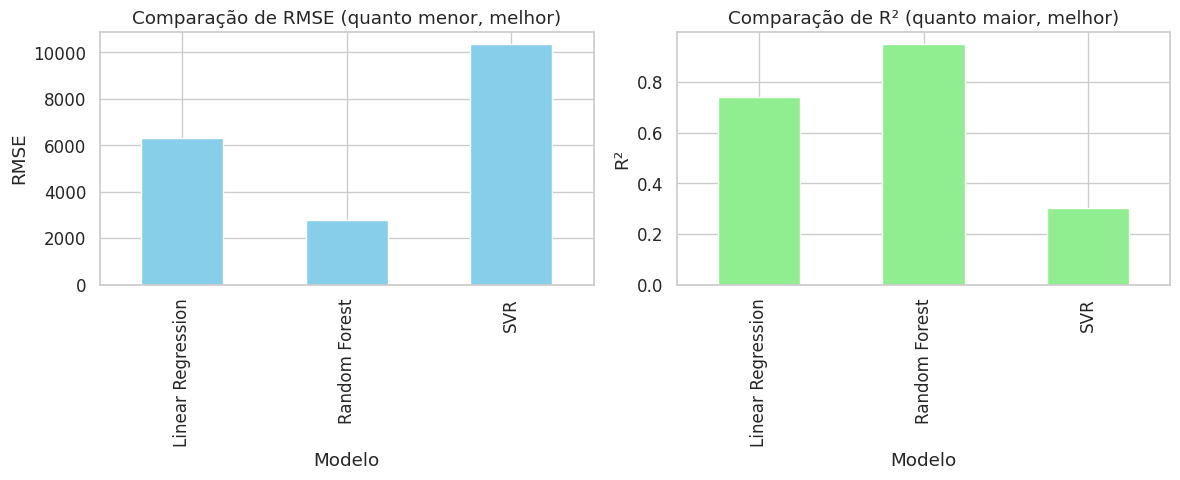

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# RMSE
resultados.plot(x='Modelo', y='RMSE', kind='bar', ax=axes[0], legend=False, color='skyblue')
axes[0].set_title("Comparação de RMSE (quanto menor, melhor)")
axes[0].set_ylabel("RMSE")

# R²
resultados.plot(x='Modelo', y='R²', kind='bar', ax=axes[1], legend=False, color='lightgreen')
axes[1].set_title("Comparação de R² (quanto maior, melhor)")
axes[1].set_ylabel("R²")

plt.tight_layout()
plt.show()
